## IMPORT NECESSARY LIBRARIES

In [ ]:
!pip install scikit-optimize

# importing PyTorch library as 't' for convenience
import torch as t

# importing other necessary libraries
import numpy as np
from torch.nn.functional import sigmoid, relu, tanh
from torch.optim import Adam
import matplotlib.pyplot as plt
import pandas as pd
import io
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from google.colab import drive
from statsmodels.imputation.mice import MICEData
from sklearn.preprocessing import StandardScaler

# importing PyTorch modules for building neural networks
from torch.nn import Tanh, Linear, Sequential, Sigmoid, Dropout
import torch as t

# importing other necessary libraries
import numpy as np
from torch.nn.functional import sigmoid, relu, tanh
from torch.optim import Adam
import matplotlib.pyplot as plt
import pandas as pd
import io
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from google.colab import drive
from statsmodels.imputation.mice import MICEData
from sklearn.preprocessing import StandardScaler

# importing PyTorch modules for building neural networks
from torch.nn import Tanh, Linear, Sequential, Sigmoid, Dropout

## UPLOAD DATA

In [ ]:
from google.colab import files
import io
uploaded = files.upload()

Saving Datathon4.csv to Datathon4.csv


In [ ]:
df = pd.read_csv(io.BytesIO(uploaded['Datathon4.csv']))
df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


## EXPLORE DATA

In [ ]:
print("\n===== Dataset Overview =====")
print("Shape of the dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())
print("\nUnique Values in Each Column:\n", df.nunique())


===== Dataset Overview =====
Shape of the dataset: (999999, 14)

Data Types:
 alx         float64
aly         float64
alz         float64
glx         float64
gly         float64
glz         float64
arx         float64
ary         float64
arz         float64
grx         float64
gry         float64
grz         float64
Activity      int64
subject      object
dtype: object

Summary Statistics:
                  alx            aly            alz            glx  \
count  999999.000000  999999.000000  999999.000000  999999.000000   
mean        1.473954      -9.618162      -0.944714      -0.023928   
std         3.751845       4.076683       5.333969       0.495758   
min       -22.146000     -19.619000     -19.373000      -2.146600   
25%         0.115100     -10.116000      -2.662400      -0.454550   
50%         1.336800      -9.644800      -0.016372      -0.070501   
75%         2.586900      -9.034300       1.371500       0.426720   
max        20.054000      21.161000      25.015000   

In [ ]:
# Group the dataset by the 'subject' column and apply the `len` function
# to each group. This counts the number of records for each patient.
# The result is a series where the index is 'subject' and the value is the count of records.
pts_with_2plusrecords = (df.groupby('subject').apply(len) >= 2)

# Filter the original dataset to include only those patients who have 2 or more records.
# This is done by first creating a boolean series `pts_with_2plusrecords` where the index is 'subject'
# and the value is True if the patient has 2 or more records, False otherwise.
# Then, using `isin` method to filter `df` so that it only includes rows where 'patient_nbr'
# matches those in the `pts_with_2plusrecords` series that are True.
patients_with_2_or_more_records_df = df[df['subject'].isin(pts_with_2plusrecords[pts_with_2plusrecords].index)]

<ipython-input-15-581eeeb9ed42>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pts_with_2plusrecords = (df.groupby('subject').apply(len) >= 2)


In [ ]:
# Update the original 'df' dataframe with the filtered dataframe.
# This step replaces the original dataset with the subset of patients who have 2 or more records.
df= patients_with_2_or_more_records_df.copy()

In [ ]:
print(df)

            alx     aly      alz       glx      gly      glz     arx     ary  \
0       2.18490 -9.6967  0.63077  0.103900 -0.84053 -0.68762 -8.6499 -4.5781   
1       2.38760 -9.5080  0.68389  0.085343 -0.83865 -0.68369 -8.6275 -4.3198   
2       2.40860 -9.5674  0.68113  0.085343 -0.83865 -0.68369 -8.5055 -4.2772   
3       2.18140 -9.4301  0.55031  0.085343 -0.83865 -0.68369 -8.6279 -4.3163   
4       2.41730 -9.3889  0.71098  0.085343 -0.83865 -0.68369 -8.7008 -4.1459   
...         ...     ...      ...       ...      ...      ...     ...     ...   
999994  0.75593 -8.9661  4.38220 -0.465680 -0.54597  0.61690 -6.6138 -2.5801   
999995  0.76348 -8.8288  4.25370 -0.465680 -0.54597  0.61690 -6.4246 -2.5633   
999996  0.76376 -8.9685  4.14250 -0.484230 -0.54221  0.63065 -6.8242 -2.5435   
999997  0.80362 -8.8894  4.12610 -0.484230 -0.54221  0.63065 -6.6379 -2.5223   
999998  0.72300 -8.9084  4.20760 -0.484230 -0.54221  0.63065 -6.5171 -2.4827   

             arz      grx      gry     

In [ ]:
df.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0,subject1


Did not run this, taken from tutorial

In [ ]:
#get the total number of unique patient IDs in the dataset after filtering for patients with 2 or more records
print(f"Total unique patient IDs with 2+ records: {len(df['subject'].unique())}")

#set random seed for reproducibility in our sampling approach
np.random.seed(42)

#randomly sample 5,000 unique patient IDs
sampled_patients = np.random.choice(df['subject'].unique(), size=5000, replace=False)

#filter the original dataframe to include only the sampled patients
df = df[df['subject'].isin(sampled_patients)].copy()

#print the total number of unique patient IDs after sampling
print(f"Total unique patient IDs with 2+ records after sampling: {len(df['subject'].unique())}")
print(df.shape)

Total unique patient IDs with 2+ records: 9


ValueError: Cannot take a larger sample than population when 'replace=False'

Did not run this, taken from tutorial

In [ ]:
# Calculating the missing threshold based on the sampled data
missing_threshold = 0.5 * len(df)

In [ ]:
# Identifying columns with more than 50% missing values in the sampled data
columns_to_drop = df.columns[df.isnull().sum() > missing_threshold]

In [ ]:
missing_values = df.isnull().sum()
missing_values, columns_to_drop

(alx         0
 aly         0
 alz         0
 glx         0
 gly         0
 glz         0
 arx         0
 ary         0
 arz         0
 grx         0
 gry         0
 grz         0
 Activity    0
 subject     0
 dtype: int64,
 Index([], dtype='object'))

No columns dropped

Did not run this in the end

In [ ]:
grouped_by_subject = df.groupby("subject")

Did not run this in the end

In [ ]:
print(grouped_by_subject.describe())

               alx                                                            \
             count      mean       std     min       25%       50%       75%   
subject                                                                        
subject1  161280.0  1.229914  4.671081 -22.075  0.095848  1.785900  2.643100   
subject2  130561.0  1.203538  3.340788 -22.074  0.012841  0.787790  2.183400   
subject3  122112.0  1.008831  3.653086 -22.076 -0.403772  0.502840  2.007600   
subject4  116736.0  0.955263  3.082181 -21.904 -0.543022  0.611945  2.341425   
subject5  119808.0  1.516916  4.413099 -22.118  0.247792  1.321400  2.199000   
subject6   98304.0  2.831852  3.563183 -22.091  1.296700  2.377200  3.595725   
subject7  104448.0  1.143347  3.383666 -22.136 -0.179973  1.021500  1.962225   
subject8  129024.0  2.242396  3.070234 -22.146  1.375300  2.254000  2.801600   
subject9   17726.0  0.839933  0.921357 -17.988  0.624518  0.783030  0.928652   

                       aly            .

<Axes: >

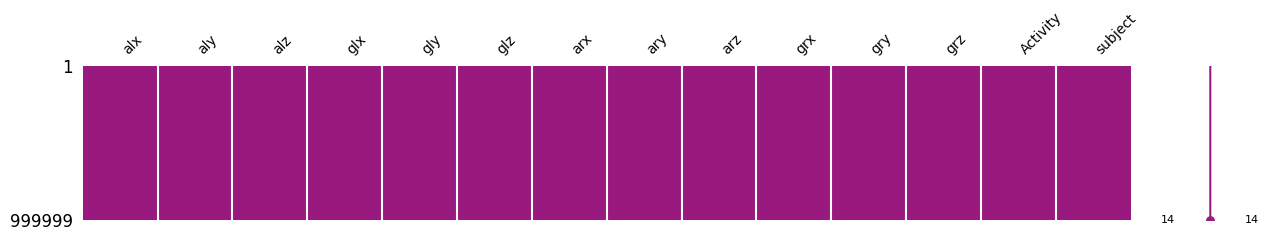

In [ ]:
# !pip install missingno
import missingno as msno

# Visualize missing values as a matrix
msno.matrix(df, figsize=(15,2), fontsize=10, color=(.6,.1,0.5))

Did not run this in the end

In [ ]:
# Dropping these columns
df_cleaned = df.drop(columns=columns_to_drop)

# Displaying the columns dropped and the first few rows of the cleaned dataframe
columns_dropped = columns_to_drop.tolist()
columns_dropped

[]

Did not run this

<Axes: >

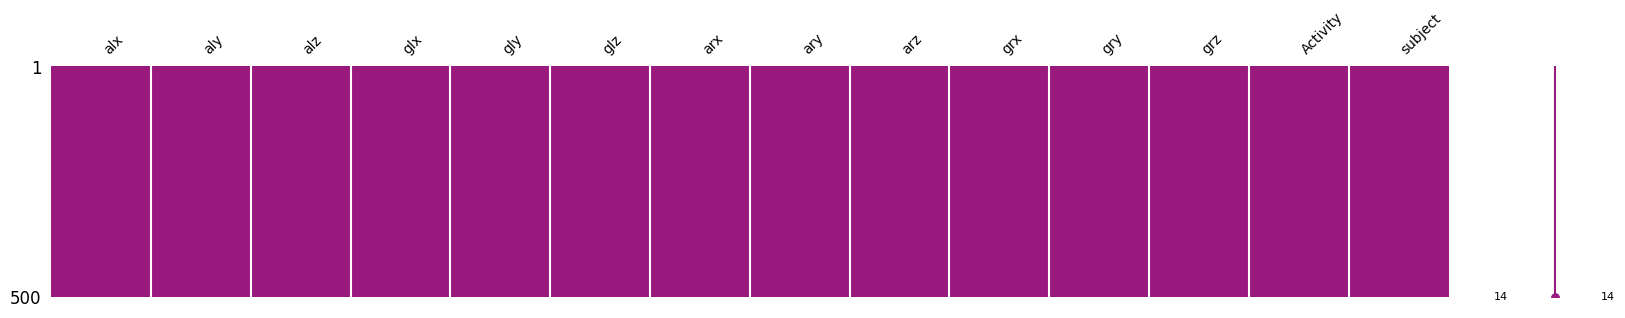

In [ ]:
# Select the first 500 rows
df_subset = df_cleaned.iloc[:500]

# Visualize missing data using missingno matrix
msno.matrix(df_subset,  figsize=(20,3), fontsize=10, color=(.6, .1, 0.5))

Did not run this

In [ ]:
# Create a new missing category
#df_cleaned['admission_type_id'].fillna('Missing', inplace=True)

# Verifying if there are any missing values left in the dataset
remaining_missing_values = df_cleaned.isnull().sum().sum()

remaining_missing_values

Did not run this

In [ ]:
# Identifying categorical columns excluding 'readmitted'
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('readmitted')  # Exclude 'readmitted' from encoding

# Applying one-hot encoding to the categorical columns
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_columns)

# Displaying the shape of the new dataframe
df_encoded_shape = df_encoded.shape
df_encoded_shape

## FEATURE ENGINEERING

Did not run this

In [ ]:
# Dropping columns with IDs and encounter_id as they are considered less useful for the analysis
#columns_to_drop_ids = ['subject']
#df_cleaned.drop(columns=columns_to_drop_ids, inplace=True)

# Displaying the first few rows of the dataset after dropping the columns
#df_cleaned.head()

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,0
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,0
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,0
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,0
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,0


Compute statistical features

In [ ]:
statistical_features = df.groupby("subject").agg(
    {
        "alx": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "aly": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "alz": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "glx": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "gly": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "glz": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "arx": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "ary": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "arz": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "grx": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "gry": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
        "grz": ["mean", "std", "min", "max", lambda x: x.skew(), lambda x: x.kurt()],
    }
)

# Display the extracted features
print(statistical_features)

               alx                                                       aly  \
              mean       std     min     max <lambda_0> <lambda_1>      mean   
subject                                                                        
subject1  1.229914  4.671081 -22.075  20.054  -1.169313   8.946263 -9.667029   
subject2  1.203538  3.340788 -22.074  20.024   0.232706  11.747878 -9.673908   
subject3  1.008831  3.653086 -22.076  20.013   0.467512   9.143583 -9.682334   
subject4  0.955263  3.082181 -21.904  20.024   0.240101  11.128826 -9.141956   
subject5  1.516916  4.413099 -22.118  20.013   0.066664   8.926443 -9.930505   
subject6  2.831852  3.563183 -22.091  20.013   0.605203  11.990953 -9.617919   
subject7  1.143347  3.383666 -22.136  20.014   0.383221  14.284430 -9.870824   
subject8  2.242396  3.070234 -22.146  20.014   0.063946  17.178908 -9.353095   
subject9  0.839933  0.921357 -17.988  19.864   0.914117  79.046058 -9.787838   

                                     ..

Time-Domain Features

In [ ]:
# Compute Root Mean Square (RMS)
df["rms_alx"] = np.sqrt(df["alx"]**2)
df["rms_aly"] = np.sqrt(df["aly"]**2)
df["rms_alz"] = np.sqrt(df["alz"]**2)

# Compute Signal Magnitude Area (SMA)
df["SMA"] = df[["alx", "aly", "alz"]].apply(lambda row: np.sum(np.abs(row)), axis=1)

# Compute Jerk (Rate of Change of Acceleration)
df["jerk_alx"] = df["alx"].diff()
df["jerk_aly"] = df["aly"].diff()
df["jerk_alz"] = df["alz"].diff()

# Compute Motion Variance
df["motion_variance"] = df[["alx", "aly", "alz"]].var(axis=1)

# Display the first few rows with new features
print(df.head())

      alx     aly      alz       glx      gly      glz     arx     ary  \
0  2.1849 -9.6967  0.63077  0.103900 -0.84053 -0.68762 -8.6499 -4.5781   
1  2.3876 -9.5080  0.68389  0.085343 -0.83865 -0.68369 -8.6275 -4.3198   
2  2.4086 -9.5674  0.68113  0.085343 -0.83865 -0.68369 -8.5055 -4.2772   
3  2.1814 -9.4301  0.55031  0.085343 -0.83865 -0.68369 -8.6279 -4.3163   
4  2.4173 -9.3889  0.71098  0.085343 -0.83865 -0.68369 -8.7008 -4.1459   

        arz      grx  ...  Activity   subject  rms_alx rms_aly  rms_alz  \
0  0.187760 -0.44902  ...         0  subject1   2.1849  9.6967  0.63077   
1  0.023595 -0.44902  ...         0  subject1   2.3876  9.5080  0.68389   
2  0.275720 -0.44902  ...         0  subject1   2.4086  9.5674  0.68113   
3  0.367520 -0.45686  ...         0  subject1   2.1814  9.4301  0.55031   
4  0.407290 -0.45686  ...         0  subject1   2.4173  9.3889  0.71098   

        SMA  jerk_alx  jerk_aly  jerk_alz  motion_variance  
0  12.51237       NaN       NaN       NaN  

# TIMESTAMP

In [ ]:
# Check for timestamp column
timestamp_columns = [col for col in df.columns if "time" in col.lower()]
if timestamp_columns:
    timestamp_col = timestamp_columns[0]  # Use the first detected timestamp column
    df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    # Compute time difference between rows
    df["time_diff"] = df[timestamp_col].diff().dt.total_seconds()

    # Check if time differences are constant (~0.02s for 50Hz)
    is_continuous = df["time_diff"].dropna().nunique() == 1 and df["time_diff"].dropna().unique()[0] == 0.02
else:
    # If no timestamp column, check row index continuity
    df["row_index_diff"] = df.index.to_series().diff()

    # If all differences are 1, the data is likely continuous
    is_continuous = df["row_index_diff"].dropna().nunique() == 1

# Display result
print("Is the dataset continuous?", is_continuous)

Is the dataset continuous? True


# SLIDING WINDOW SEGMENTATION

In [ ]:
from scipy.stats import skew, kurtosis
from scipy.fftpack import fft

# Define sliding window parameters
sampling_rate = 50  # Hz (50 samples per second)
window_size = 2 * sampling_rate  # 2-second windows (100 samples)
stride = window_size // 2  # 50% overlap (shifts by 1 second)

# List of sensor columns
sensor_columns = ["alx", "aly", "alz", "glx", "gly", "glz", "arx", "ary", "arz", "grx", "gry", "grz"]

# Function to compute features for each window
def extract_features(window):
    features = []

    for col in sensor_columns:
        data = window[col].values

        # Statistical Features
        features.append(np.mean(data))  # Mean
        features.append(np.std(data))   # Standard Deviation
        features.append(np.min(data))   # Min
        features.append(np.max(data))   # Max
        features.append(skew(data))     # Skewness
        features.append(kurtosis(data)) # Kurtosis

        # Time-Series Features
        features.append(np.sqrt(np.mean(data**2)))  # RMS
        features.append(np.sum(np.abs(data)))       # SMA
        features.append(np.mean(np.diff(data)))     # Jerk

        # Frequency-Domain Features (FFT)
        fft_values = np.abs(fft(data))  # Compute FFT
        features.append(np.mean(fft_values))  # FFT Mean
        features.append(np.sum(fft_values**2))  # FFT Energy

    return features

# Apply sliding window segmentation with feature extraction
X_features = []
y_labels = []

for i in range(0, len(df) - window_size, stride):
    window = df.iloc[i : i + window_size]  # Extract window
    features = extract_features(window)  # Extract features
    label = df["Activity"].iloc[i + window_size // 2]  # Assign label at window center

    X_features.append(features)
    y_labels.append(label)

# Convert to NumPy arrays
X = np.array(X_features)
y = np.array(y_labels)

# Print shapes of extracted features
print("Feature Matrix Shape:", X.shape)  # (num_windows, num_features)
print("Labels Shape:", y.shape)  # (num_windows,)

Feature Matrix Shape: (19998, 132)
Labels Shape: (19998,)


# RECURRENT NEURAL NETWORK

Train recurrent neural network

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # X is the extracted feature matrix

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))  # y is the label array

# Reshape input for LSTM (samples, timesteps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_encoded, test_size=0.2, random_state=42)

# Build LSTM Model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(y_encoded.shape[1], activation="softmax")  # Number of activity classes
])

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6521 - loss: 1.5097 - val_accuracy: 0.8173 - val_loss: 0.5127
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8178 - loss: 0.5184 - val_accuracy: 0.8648 - val_loss: 0.3521
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8461 - loss: 0.4036 - val_accuracy: 0.8798 - val_loss: 0.3148
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8595 - loss: 0.3578 - val_accuracy: 0.8855 - val_loss: 0.2801
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8735 - loss: 0.3182 - val_accuracy: 0.8907 - val_loss: 0.2577
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8796 - loss: 0.3015 - val_accuracy: 0.8985 - val_loss: 0.2502
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8868 - loss: 0.2806 - val_accuracy: 0.8990 - val_loss: 0.2480
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8935 - loss: 0.2690 - val_accuracy: 0

# PERFORMANCE METRICS

##Training & Validation Loss/Accuracy

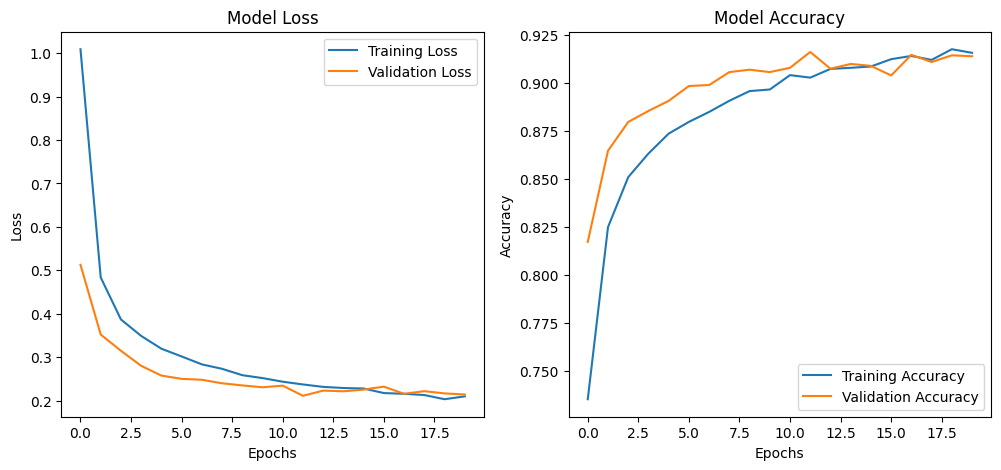

In [ ]:
import matplotlib.pyplot as plt

# Extract training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()

## Confusion matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


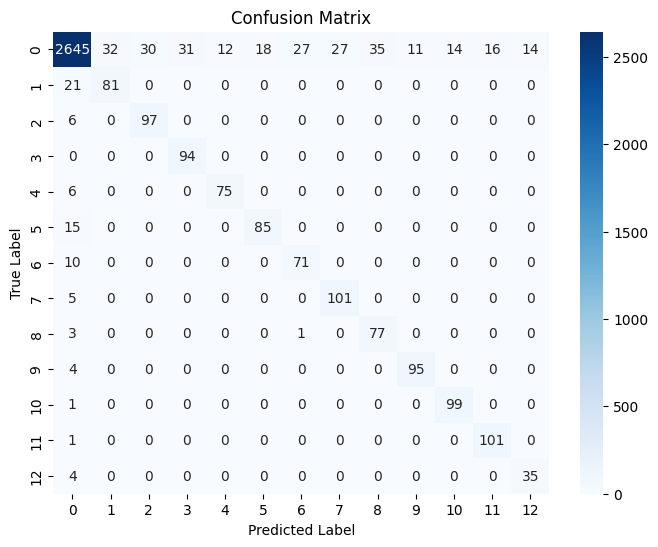

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Get model predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.categories_[0], yticklabels=encoder.categories_[0])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Convert class labels to strings
target_names = [str(c) for c in encoder.categories_[0]]

# Print classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      2912
           1       0.72      0.79      0.75       102
           2       0.76      0.94      0.84       103
           3       0.75      1.00      0.86        94
           4       0.86      0.93      0.89        81
           5       0.83      0.85      0.84       100
           6       0.72      0.88      0.79        81
           7       0.79      0.95      0.86       106
           8       0.69      0.95      0.80        81
           9       0.90      0.96      0.93        99
          10       0.88      0.99      0.93       100
          11       0.86      0.99      0.92       102
          12       0.71      0.90      0.80        39

    accuracy                           0.91      4000
   macro avg       0.80      0.93      0.86      4000
weighted avg       0.92      0.91      0.92      4000

